In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [3]:
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']
    
    bmi = weight / (height ** 2)

    state['bmi'] = round(bmi, 2)

    return state

In [4]:
def categorize_bmi(state: BMIState) -> BMIState:
    bmi = state['bmi']
    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state

In [5]:
graph = StateGraph(BMIState)

graph.add_node('CalculateBMI', calculate_bmi)
graph.add_node('CategorizeBMI', categorize_bmi)

graph.add_edge(START, 'CalculateBMI')
graph.add_edge('CalculateBMI', 'CategorizeBMI')
graph.add_edge('CategorizeBMI', END)

workflow = graph.compile()

In [6]:
initial_state = {'weight_kg': 56, 'height_m': 1.62}

final_state = workflow.invoke(initial_state)

print(final_state)

{'weight_kg': 56, 'height_m': 1.62, 'bmi': 21.34, 'category': 'Normal'}


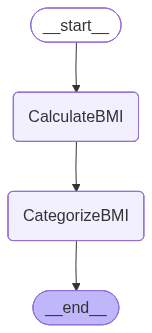

In [7]:
workflow

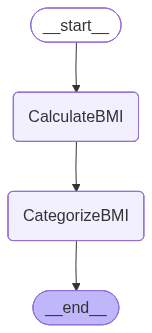

In [8]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [9]:
workflow.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'CalculateBMI': Node(id='CalculateBMI', name='CalculateBMI', data=CalculateBMI(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'CategorizeBMI': Node(id='CategorizeBMI', name='CategorizeBMI', data=CategorizeBMI(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='CalculateBMI', target='CategorizeBMI', data=None, conditional=False), Edge(source='__start__', target='CalculateBMI', data=None, conditional=False), Edge(source='CategorizeBMI', target='__end__', data=None, conditional=False)])

In [10]:
workflow.get_graph().draw_ascii()

'  +-----------+    \n  | __start__ |    \n  +-----------+    \n        *          \n        *          \n        *          \n+--------------+   \n| CalculateBMI |   \n+--------------+   \n        *          \n        *          \n        *          \n+---------------+  \n| CategorizeBMI |  \n+---------------+  \n        *          \n        *          \n        *          \n   +---------+     \n   | __end__ |     \n   +---------+     '